In [ ]:
!wget -P data/full_dataset/ https://storage.googleapis.com/gresearch/goemotions/data/full_dataset/goemotions_1.csv
!wget -P data/full_dataset/ https://storage.googleapis.com/gresearch/goemotions/data/full_dataset/goemotions_2.csv
!wget -P data/full_dataset/ https://storage.googleapis.com/gresearch/goemotions/data/full_dataset/goemotions_3.csv

--2026-03-15 17:06:25--  https://storage.googleapis.com/gresearch/goemotions/data/full_dataset/goemotions_1.csv
Resolving storage.googleapis.com (storage.googleapis.com)... 173.194.216.207, 192.178.219.207, 173.194.217.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|173.194.216.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 14174600 (14M) [application/octet-stream]
Saving to: ‘data/full_dataset/goemotions_1.csv’

goemotions_1.csv    100%[===================>]  13.52M  --.-KB/s    in 0.1s    

2026-03-15 17:06:26 (91.3 MB/s) - ‘data/full_dataset/goemotions_1.csv’ saved [14174600/14174600]

--2026-03-15 17:06:26--  https://storage.googleapis.com/gresearch/goemotions/data/full_dataset/goemotions_2.csv
Resolving storage.googleapis.com (storage.googleapis.com)... 173.194.216.207, 192.178.219.207, 173.194.217.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|173.194.216.207|:443... connected.
HTTP request sent, awaiti

In [ ]:
pip install pandas matplotlib seaborn nltk wordcloud

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Total samples: 211225
                                                text       id  \
0                                    That game hurt.  eew5j0j   
1   >sexuality shouldn’t be a grouping category I...  eemcysk   
2     You do right, if you don't care then fuck 'em!  ed2mah1   
3                                 Man I love reddit.  eeibobj   
4  [NAME] was nowhere near them, he was by the Fa...  eda6yn6   

                author            subreddit    link_id   parent_id  \
0                Brdd9                  nrl  t3_ajis4z  t1_eew18eq   
1          TheGreen888     unpopularopinion  t3_ai4q37   t3_ai4q37   
2             Labalool          confessions  t3_abru74  t1_ed2m7g7   
3        MrsRobertshaw             facepalm  t3_ahulml   t3_ahulml   
4  American_Fascist713  starwarsspeculation  t3_ackt2f  t1_eda65q2   

    created_utc  rater_id  example_very_unclear  admiration  ...  love  \
0  1.548381e+09         1                 False           0  ...     0   
1  1.548084e+09   

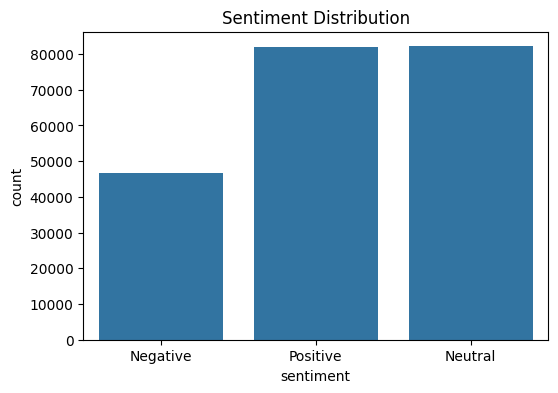

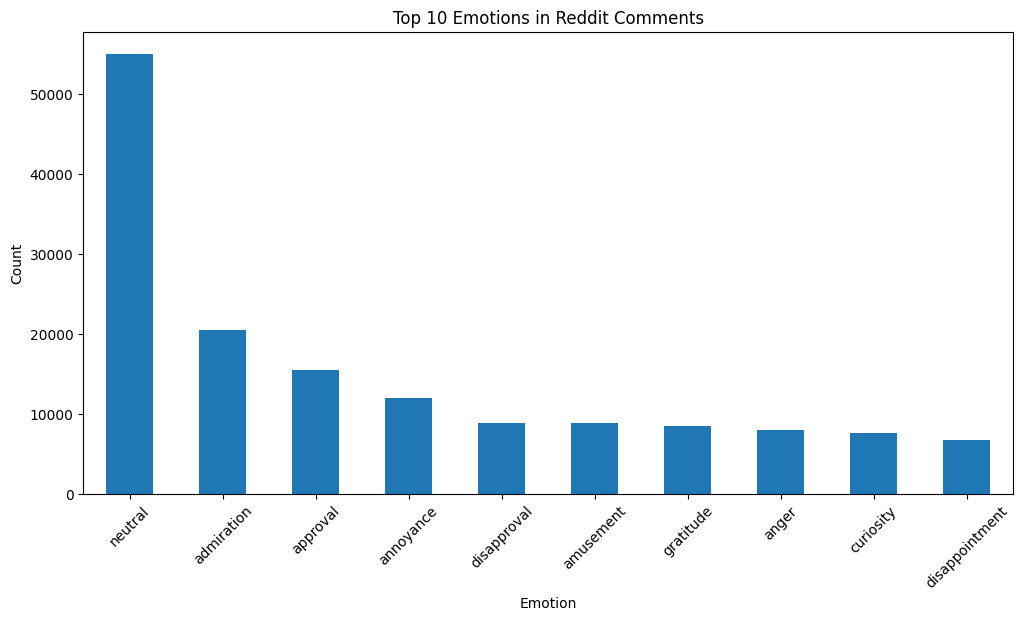

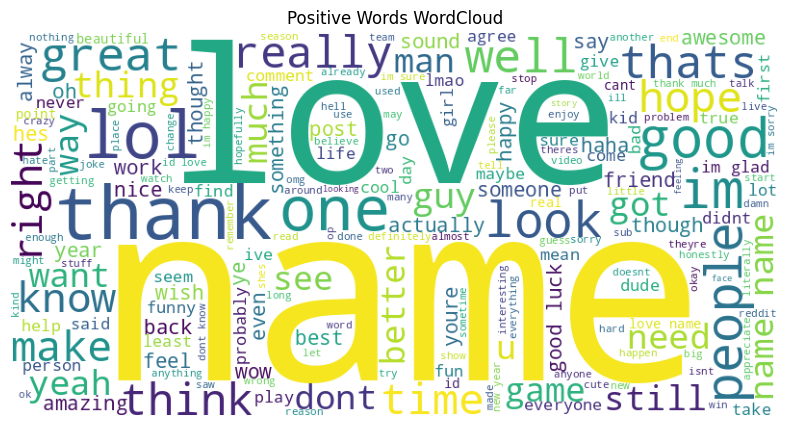

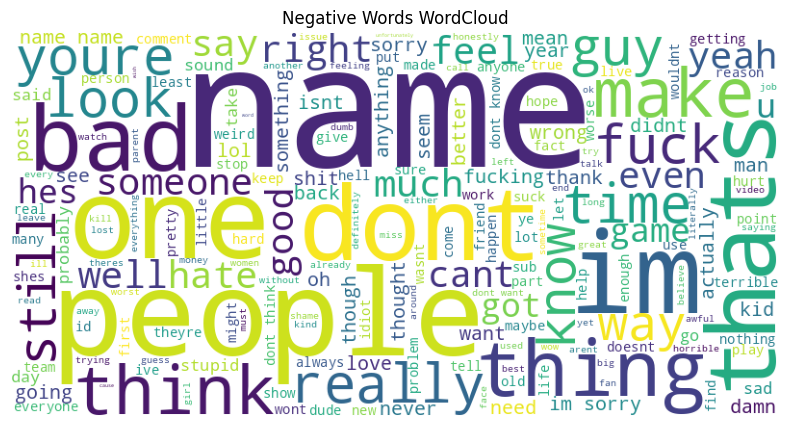

In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

# -----------------------------
# 1. Load the Dataset
# -----------------------------

file1 = "data/full_dataset/goemotions_1.csv"
file2 = "data/full_dataset/goemotions_2.csv"
file3 = "data/full_dataset/goemotions_3.csv"

df1 = pd.read_csv(file1)
df2 = pd.read_csv(file2)
df3 = pd.read_csv(file3)

df = pd.concat([df1, df2, df3], ignore_index=True)

print("Total samples:", len(df))
print(df.head())

# -----------------------------
# 2. Keep Only Relevant Columns
# -----------------------------

# The previous definition of emotion_columns was too broad and included non-numeric columns.
# Based on the dataset structure, emotion columns are typically from 'admiration' to 'neutral'.
emotion_columns = df.loc[:, 'admiration':'neutral'].columns

# -----------------------------
# 3. Convert Emotion Labels
# -----------------------------

df['emotion'] = df[emotion_columns].idxmax(axis=1)

# -----------------------------
# 4. Map Emotion → Sentiment
# -----------------------------

positive_emotions = [
'admiration','amusement','approval','caring','desire',
'excitement','gratitude','joy','love','optimism','pride'
]

negative_emotions = [
'anger','annoyance','disappointment','disapproval',
'embarrassment','fear','grief','nervousness','remorse',
'sadness'
]

def emotion_to_sentiment(emotion):

    if emotion in positive_emotions:
        return "Positive"

    elif emotion in negative_emotions:
        return "Negative"

    else:
        return "Neutral"

df['sentiment'] = df['emotion'].apply(emotion_to_sentiment)

# -----------------------------
# 5. Text Cleaning
# -----------------------------

stop_words = set(stopwords.words('english'))

def clean_text(text):

    text = text.lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"@\w+", "", text)

    text = re.sub(r"[^a-z\s]", "", text)

    words = text.split()

    words = [w for w in words if w not in stop_words]

    return " ".join(words)

df['clean_text'] = df['text'].apply(clean_text)

# Remove empty rows
df = df[df['clean_text'].str.strip() != ""]

print("Clean dataset size:", len(df))

# -----------------------------
# 6. Save Clean Dataset
# -----------------------------

df.to_csv("clean_goemotions_dataset.csv", index=False)

# -----------------------------
# 7. Sentiment Distribution Graph
# -----------------------------

plt.figure(figsize=(6,4))

sns.countplot(data=df, x='sentiment')

plt.title("Sentiment Distribution")

plt.savefig("sentiment_distribution.png")

plt.show()

# -----------------------------
# 8. Top Emotions Graph
# -----------------------------

plt.figure(figsize=(12,6))

df['emotion'].value_counts().head(10).plot(kind='bar')

plt.title("Top 10 Emotions in Reddit Comments")

plt.xlabel("Emotion")

plt.ylabel("Count")

plt.xticks(rotation=45)

plt.savefig("top_emotions.png")

plt.show()

# -----------------------------
# 9. WordCloud for Positive Sentiment
# -----------------------------

positive_text = " ".join(df[df['sentiment']=="Positive"]['clean_text'])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(positive_text)

plt.figure(figsize=(10,5))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Positive Words WordCloud")

plt.savefig("positive_wordcloud.png")

plt.show()

# -----------------------------
# 10. WordCloud for Negative Sentiment
# -----------------------------

negative_text = " ".join(df[df['sentiment']=="Negative"]['clean_text'])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(negative_text)

plt.figure(figsize=(10,5))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Negative Words WordCloud")

plt.savefig("negative_wordcloud.png")

plt.show()

In [ ]:
df.head()

,text,id,author,subreddit,link_id,parent_id,created_utc,rater_id,example_very_unclear,admiration,...,pride,realization,relief,remorse,sadness,surprise,neutral,emotion,sentiment,clean_text
0,That game hurt.,eew5j0j,Brdd9,nrl,t3_ajis4z,t1_eew18eq,1.548381e+09,1,False,0,...,0,0,0,0,1,0,0,sadness,Negative,game hurt
1,>sexuality shouldn’t be a grouping category I...,eemcysk,TheGreen888,unpopularopinion,t3_ai4q37,t3_ai4q37,1.548084e+09,37,True,0,...,0,0,0,0,0,0,0,admiration,Positive,sexuality shouldnt grouping category makes dif...
2,"You do right, if you don't care then fuck 'em!",ed2mah1,Labalool,confessions,t3_abru74,t1_ed2m7g7,1.546428e+09,37,False,0,...,0,0,0,0,0,0,1,neutral,Neutral,right dont care fuck em
3,Man I love reddit.,eeibobj,MrsRobertshaw,facepalm,t3_ahulml,t3_ahulml,1.547965e+09,18,False,0,...,0,0,0,0,0,0,0,love,Positive,man love reddit
4,"[NAME] was nowhere near them, he was by the Fa...",eda6yn6,American_Fascist713,starwarsspeculation,t3_ackt2f,t1_eda65q2,1.546669e+09,2,False,0,...,0,0,0,0,0,0,1,neutral,Neutral,name nowhere near falcon


In [ ]:
# Filter out neutral sentiments
df_filtered = df[df['sentiment'] != 'Neutral']

# Select only 'sentiment' and 'clean_text' columns
df_final = df_filtered[['sentiment', 'clean_text']]

# Display the first few rows of the new DataFrame
print("Shape of the filtered DataFrame:", df_final.shape)
display(df_final.head())

# Save the DataFrame to a CSV file
df_final.to_csv("non_neutral_sentiments.csv", index=False)
print("Saved non_neutral_sentiments.csv")

Shape of the filtered DataFrame: (128676, 2)


,sentiment,clean_text
0,Negative,game hurt
1,Positive,sexuality shouldnt grouping category makes dif...
3,Positive,man love reddit
5,Positive,right considering important document know damn...
6,Negative,isnt big hes still quite popular ive heard thi...


Saved non_neutral_sentiments.csv


In [ ]:
df_final['encoded_sentiment'] = df_final['sentiment'].map({'Negative': 0, 'Positive': 1})

print("Shape of the DataFrame with encoded sentiment:", df_final.shape)
display(df_final.head())

df_final.to_csv("encoded_sentiments.csv", index=False)
print("Saved encoded_sentiments.csv")

Shape of the DataFrame with encoded sentiment: (128676, 3)


/tmp/ipykernel_551/1583106162.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final['encoded_sentiment'] = df_final['sentiment'].map({'Negative': 0, 'Positive': 1})


,sentiment,clean_text,encoded_sentiment
0,Negative,game hurt,0
1,Positive,sexuality shouldnt grouping category makes dif...,1
3,Positive,man love reddit,1
5,Positive,right considering important document know damn...,1
6,Negative,isnt big hes still quite popular ive heard thi...,0


Saved encoded_sentiments.csv


In [ ]:
final_df_for_model = df_final[['clean_text', 'encoded_sentiment']].rename(columns={'encoded_sentiment': 'sentiment'})

print("Shape of the final DataFrame:", final_df_for_model.shape)
display(final_df_for_model.head())

Shape of the final DataFrame: (128676, 2)


,clean_text,sentiment
0,game hurt,0
1,sexuality shouldnt grouping category makes dif...,1
3,man love reddit,1
5,right considering important document know damn...,1
6,isnt big hes still quite popular ive heard thi...,0


/tmp/ipykernel_551/3025835907.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=final_df_for_model, x='sentiment', palette='viridis')


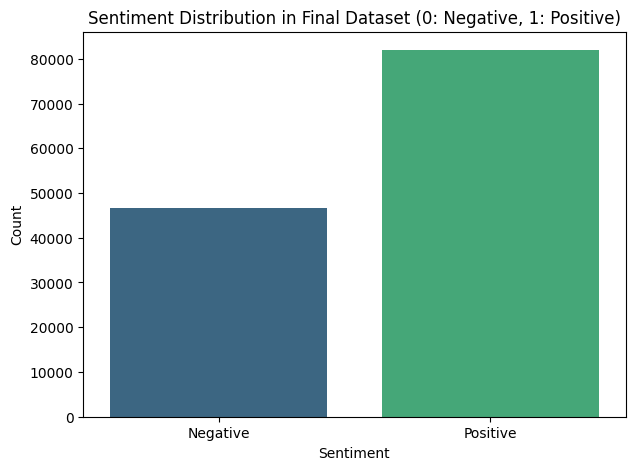

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))
sns.countplot(data=final_df_for_model, x='sentiment', palette='viridis')
plt.title('Sentiment Distribution in Final Dataset (0: Negative, 1: Positive)')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['Negative', 'Positive'])
plt.savefig('final_sentiment_distribution.png')
plt.show()

In [ ]:
from google.colab import files
files.download('final_sentiment_distribution.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>